In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from google.colab import files

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

from sklearn.ensemble import IsolationForest
from sklearn.svm import OneClassSVM

from sklearn.model_selection import train_test_split

In [2]:
uploaded = files.upload()

Saving Train.csv to Train.csv


In [3]:
df = pd.read_csv("Train.csv")

In [4]:
print("Dataset Shape:",df.shape)
df.head()

Dataset Shape: (10999, 12)


,ID,Warehouse_block,Mode_of_Shipment,Customer_care_calls,Customer_rating,Cost_of_the_Product,Prior_purchases,Product_importance,Gender,Discount_offered,Weight_in_gms,Reached.on.Time_Y.N
0,1,D,Flight,4,2,177,3,low,F,44,1233,1
1,2,F,Flight,4,5,216,2,low,M,59,3088,1
2,3,A,Flight,2,2,183,4,low,M,48,3374,1
3,4,B,Flight,3,3,176,4,medium,M,10,1177,1
4,5,C,Flight,2,2,184,3,medium,F,46,2484,1


In [6]:
X = df.drop("Reached.on.Time_Y.N",axis=1)
y = df["Reached.on.Time_Y.N"]

In [7]:
num_cols = X.select_dtypes(include=['int64','float64']).columns
cat_cols = X.select_dtypes(include=['object']).columns
print("Numerical:",num_cols)
print("Categorical:",cat_cols)

Numerical: Index(['ID', 'Customer_care_calls', 'Customer_rating', 'Cost_of_the_Product',
       'Prior_purchases', 'Discount_offered', 'Weight_in_gms'],
      dtype='object')
Categorical: Index(['Warehouse_block', 'Mode_of_Shipment', 'Product_importance', 'Gender'], dtype='object')


In [8]:
num_pipeline = Pipeline([

    ("scaler",StandardScaler())

])
cat_pipeline = Pipeline([

    ("encoder",OneHotEncoder(handle_unknown='ignore'))

])
preprocessor = ColumnTransformer([

    ("num",num_pipeline,num_cols),

    ("cat",cat_pipeline,cat_cols)

])

In [9]:
X_train,X_test = train_test_split(
    X,
    test_size=0.3,
    random_state=1
)

In [11]:
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)
print("Processed Shape:",X_train_processed.shape)

Processed Shape: (7699, 20)


In [12]:
iso_model = IsolationForest(

    n_estimators=150,
    contamination=0.06,
    random_state=1

)
iso_model.fit(X_train_processed)
iso_pred = iso_model.predict(X_test_processed)
iso_pred = np.where(iso_pred==-1,1,0)
print("\nIsolation Forest Results")
print("Anomalies detected:",np.sum(iso_pred))


Isolation Forest Results
Anomalies detected: 225


In [13]:
svm_model = OneClassSVM(

    kernel='rbf',
    gamma=0.02,
    nu=0.04

)
svm_model.fit(X_train_processed)
svm_pred = svm_model.predict(X_test_processed)
svm_pred = np.where(svm_pred==-1,1,0)
print("\nOneClass SVM Results")
print("Anomalies detected:",np.sum(svm_pred))


OneClass SVM Results
Anomalies detected: 140


In [17]:
gammas = [0.002,0.02,0.2]
for g in gammas:

    model = OneClassSVM(

        kernel='rbf',
        gamma=g,
        nu=0.04
    )
    model.fit(X_train_processed)
    pred = model.predict(X_test_processed)
    pred = np.where(pred==-1,1,0)
    print("Gamma =",g,"Anomalies:",np.sum(pred))

Gamma = 0.002 Anomalies: 144
Gamma = 0.02 Anomalies: 140
Gamma = 0.2 Anomalies: 214


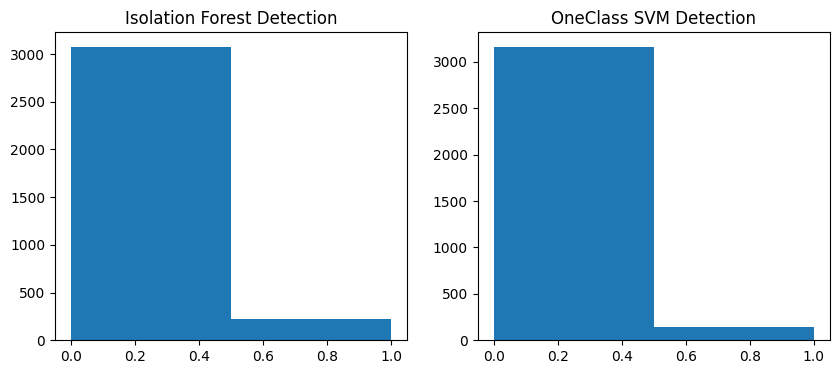

In [18]:
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.hist(iso_pred,bins=2)
plt.title("Isolation Forest Detection")
plt.subplot(1,2,2)
plt.hist(svm_pred,bins=2)
plt.title("OneClass SVM Detection")
plt.show()